In [26]:
import sys
import os
import numpy as np
import pennylane as qml
import timeit
import matplotlib.pyplot as plt


In [ ]:

sys.path.append(os.path.abspath(".."))

from src.grover import GroverAlgorithm
from src.tsp import TSPInstance


In [28]:

def run_tsp_grover_pipeline(num_cities, device_name="default.qubit"):
    # 1. Setup TSP Instance
    tsp = TSPInstance(num_cities=num_cities, seed=42)
    best_tour, min_cost = tsp.get_optimal_tour()
    
    # 2. Find target indices (the constrained subset of valid tours)
    target_indices = []
    for i, tour in enumerate(tsp.all_tours):
        if np.isclose(tsp.calculate_cost(tour), min_cost):
            target_indices.append(i)
            
    # 3. Setup Grover Encoding
    num_feasible = len(tsp.all_tours)
    num_qubits = int(np.ceil(np.log2(num_feasible)))
    grover = GroverAlgorithm(num_qubits=num_qubits)
    
    # Convert indices to bitstrings for the oracle
    target_bitstrings = [format(idx, f'0{num_qubits}b') for idx in target_indices]
    
    # 4. Device and QNode Setup
    dev = qml.device(device_name, wires=num_qubits)
    qnode = grover.get_qnode(device=dev, interface="jax")
    
    # 5. Measure Metrics
    specs = qml.specs(qnode)(target_bitstrings)
    probs = qnode(target_bitstrings)
    
    # Calculate Success Probability
    success_prob = np.sum([np.array(probs)[idx] for idx in target_indices])
    
    print(f"--- TSP {num_cities} Cities Baseline ---")
    print(f"Device: {device_name}")
    print(f"Optimal Tour: {best_tour} | Min Cost: {min_cost:.4f}")
    print(f"Qubits Required: {num_qubits}")
    print(f"Circuit Depth: {specs['resources'].depth}")
    print(f"Success Probability: {success_prob:.4f}")
    
    # 6. Visualize
    tsp.visualize(tour=best_tour, title=f"{num_cities}-City TSP Result")
    
    return qnode, probs




--- TSP 3 Cities Baseline ---
Device: lightning.qubit
Optimal Tour: (0, 2, 1) | Min Cost: 2.0524
Qubits Required: 1
Circuit Depth: 1
Success Probability: 1.0000


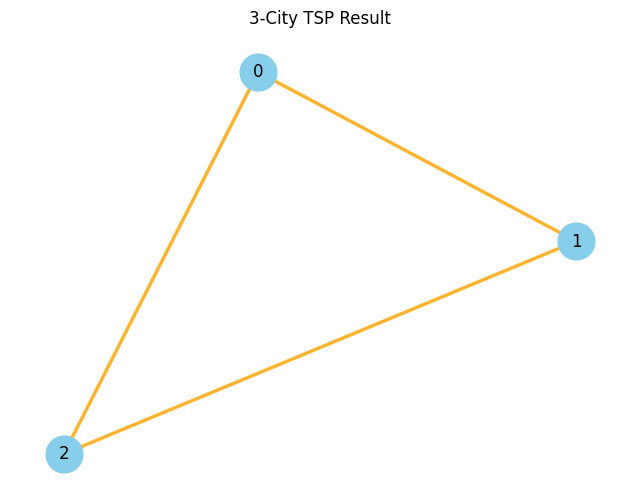

In [33]:
# Execute for 4 cities
qnode, final_probs = run_tsp_grover_pipeline(num_cities=3, device_name="lightning.qubit")

--- TSP 3 Cities Baseline ---
Device: default.qubit
Optimal Tour: (0, 2, 1) | Min Cost: 2.0524
Qubits Required: 1
Circuit Depth: 1
Success Probability: 1.0000


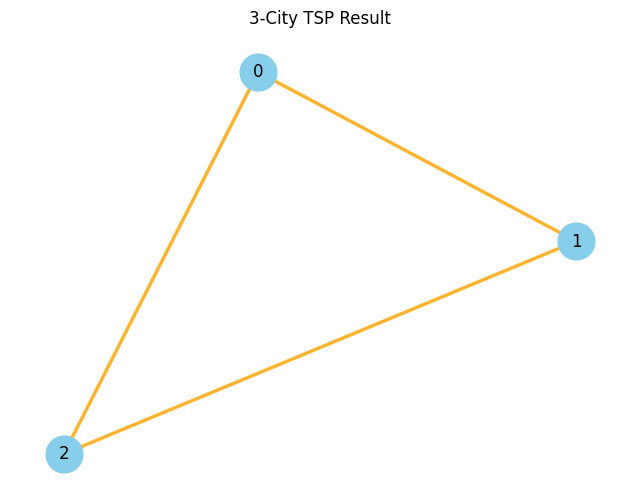

In [35]:
# Execute for 4 cities
qnode, final_probs = run_tsp_grover_pipeline(num_cities=3)